<a href="https://colab.research.google.com/github/Carereen/image-processing/blob/main/Assignment3_Sec2_6853800122.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np
import sys

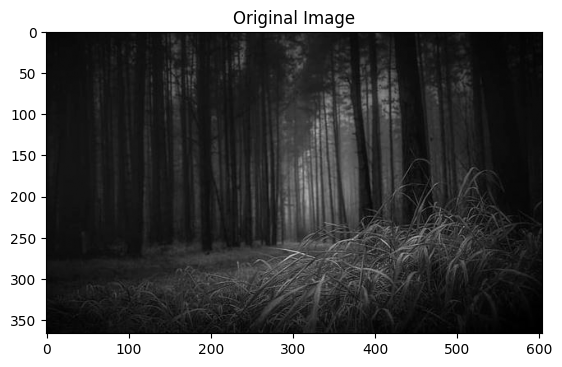

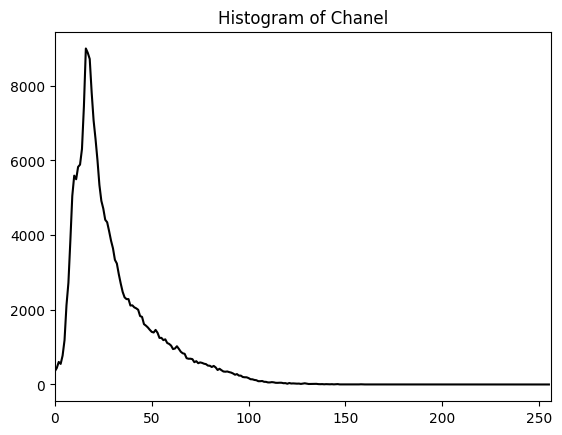

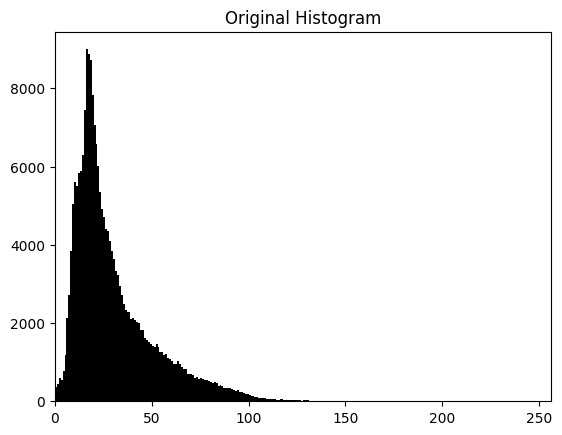

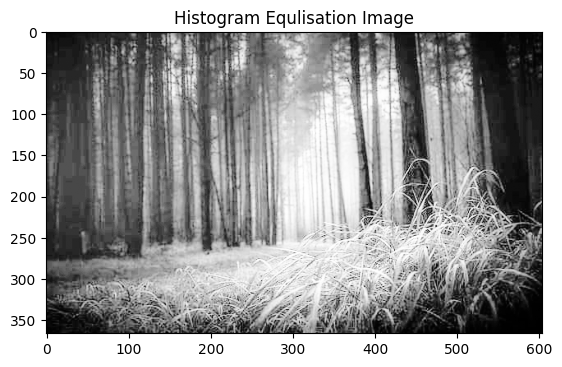

In [ ]:
path = "/content/drive/My Drive/2568-term2/image/Lab3-Image/homework3/"
image_name1 = 'image1.jpg'
image_gray = cv2.imread(path + image_name1, 0)

if image_gray is None:
  print(f"Image file not found. Please check the path:{path + image_name1 }. ")
  sys.exit()

plt.title("Original Image")
plt.imshow(image_gray, cmap='gray')
plt.show()

color = ('b', 'g', 'r')
plt.title("Histogram of Chanel")

histr = cv2.calcHist([image_gray], [0], None, [256], [0, 256])
plt.plot(histr, color = "black")
plt.xlim([0, 256])
plt.show()

plt.title("Original Histogram")
plt.hist(image_gray.ravel(), bins = 256, range = [0, 256], color = 'black', alpha = 1.0)
plt.xlim([0, 256])
plt.show()

plt.title("Histogram Equlisation Image")
image_equ = cv2.equalizeHist(image_gray)
plt.imshow(image_equ, cmap='gray')
plt.show()

# plt.title("Equalized Histogram")
# plt.hist(image_equ.ravel(), bins = 256, range = [0, 256], color = 'gray', alpha = 0.7)
# plt.xlim([0, 256])
# plt.show()

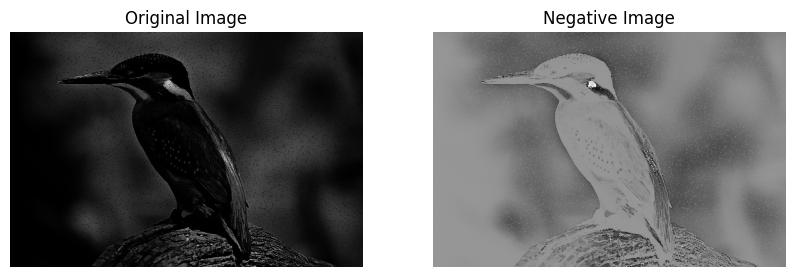

In [ ]:
path = "/content/drive/My Drive/2568-term2/image/Lab3-Image/homework3/"
image_name2 = 'image2.jpg'
image_gray = cv2.imread(path + image_name2, 0)

if image_gray is None:
  print(f"Image file not found. Please check the path:{path + image_name2 }. ")
  sys.exit()

image_negative = 150 - image_gray

plt.figure(figsize = (10, 5))
plt.subplot(121)
plt.imshow(image_gray, cmap = 'gray', vmin = 0, vmax = 255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(122)
plt.imshow(image_negative, cmap = 'gray', vmin = 0, vmax = 255)
plt.title("Negative Image")
plt.axis("off")
plt.show()

(([], []), ([], []))

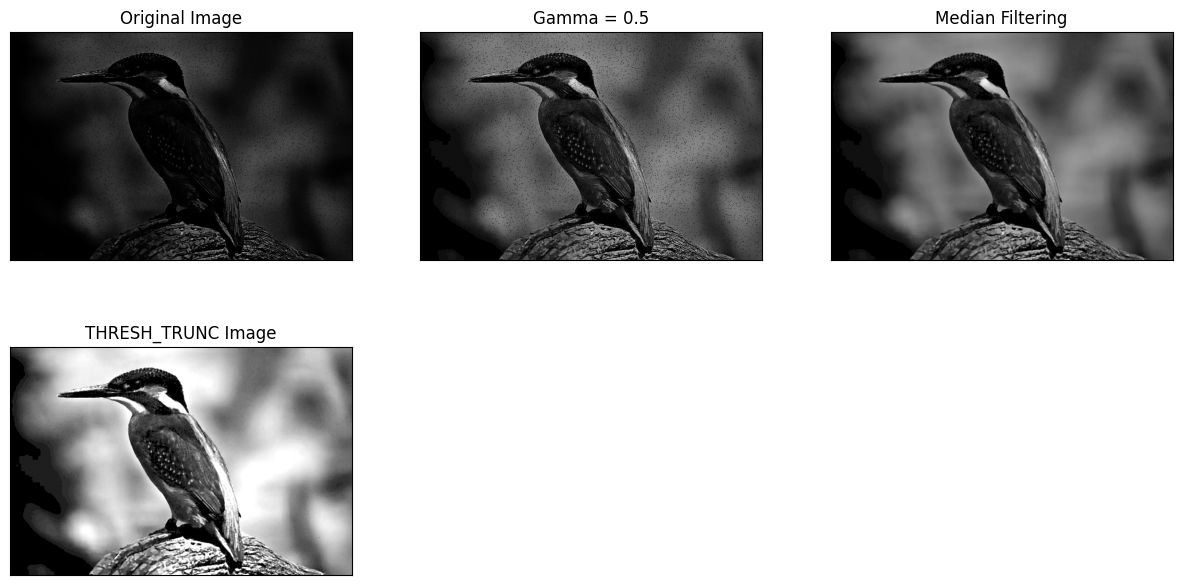

In [ ]:
path = "/content/drive/My Drive/2568-term2/image/Lab3-Image/homework3/"
image_name2 = 'image2.jpg'
image_gray = cv2.imread(path + image_name2, 0)

if image_gray is None:
  print(f"Image file not found. Please check the path:{path + image_name2 }. ")
  sys.exit()

image_gamma = np.array(255 * (image_gray / 255.0) ** 0.5, dtype = 'uint8')

image_median = cv2.medianBlur(image_gamma, 3)

ret, thresh3 = cv2.threshold(image_median, 127, 255, cv2.THRESH_TRUNC)

fig = plt.figure(figsize = (15, 15))
plt.subplot(131), plt.imshow(image_gray, cmap = 'gray'), plt.title("Original Image")
plt.xticks([]), plt.yticks([])

plt.subplot(132), plt.imshow(image_gamma, cmap = 'gray'), plt.title("Gamma = 0.5")
plt.xticks([]), plt.yticks([])

plt.subplot(133), plt.imshow(image_median, cmap = 'gray'), plt.title('Median Filtering')
plt.xticks([]), plt.yticks([])

plt.subplot(234), plt.imshow(thresh3, cmap = 'gray'), plt.title('THRESH_TRUNC Image')
plt.xticks([]), plt.yticks([])



ภาพขาวดำต้นฉบับถูกปรับความสว่างด้วย Gamma Correction (γ = 0.5) เพื่อเพิ่มรายละเอียดในส่วนที่มืด จากนั้นใช้ Median Filter ขนาด 3×3 เพื่อลดสัญญาณรบกวนขนาดเล็ก และสุดท้ายปรับค่าความสว่างด้วย Threshold แบบ TRUNC ที่ค่า 127 เพื่อจำกัดส่วนที่สว่างเกินไป

(([], []), ([], []))

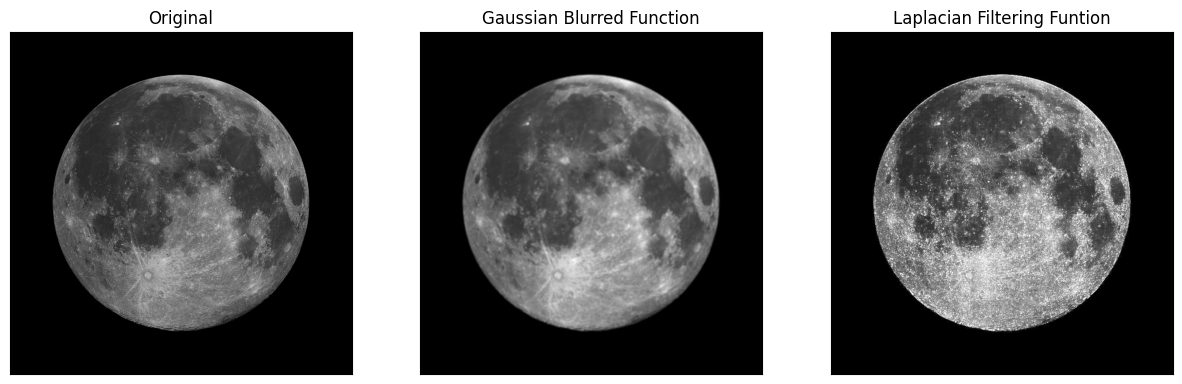

In [ ]:
path = "/content/drive/My Drive/2568-term2/image/Lab3-Image/homework3/"
image_name3 = 'image3.png'
image_gray = cv2.imread(path + image_name3, 0)

if image_gray is None:
    print(f'Image file not found. Please check the path: {path + image_name3}.')
    sys.exit()

unsharp_image = cv2.GaussianBlur(image_gray, (7, 7), 0)

lap = cv2.Laplacian(image_gray, cv2.CV_64F)
lap = cv2.convertScaleAbs(lap)
sharpen_lap = cv2.add(image_gray, lap)

fig = plt.figure(figsize=(15, 15))
plt.subplot(131), plt.imshow(image_gray, cmap = 'gray'), plt.title('Original')
plt.xticks([]), plt.yticks([])

plt.subplot(132), plt.imshow(unsharp_image, cmap = 'gray'), plt.title('Gaussian Blurred Function')
plt.xticks([]), plt.yticks([])

plt.subplot(133), plt.imshow(sharpen_lap, cmap = 'gray'), plt.title('Laplacian Filtering Funtion')
plt.xticks([]), plt.yticks([])